# Kovasznay Flow: Accuracy Analysis

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, LogFormatterMathtext, NullLocator
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
RUNS_ROOT = ROOT / "runs"

print("ROOT:", ROOT.resolve())
print("RUNS_ROOT:", RUNS_ROOT.resolve())

ROOT: /Users/klemens/Projects/EqNN-Equilibrium-Neural-Network/practical
RUNS_ROOT: /Users/klemens/Projects/EqNN-Equilibrium-Neural-Network/practical/runs


In [2]:
PROBLEM_NAME = "kovasznay"
PROBLEM_NAME_DISPLAY = "Kovasznay Flow"
SWEEP_NAME = "sweep_20260421-083905_v6_rtx4090"
MAIN_METHOD_NAMES = ["adam", "lbfgs", "gnng_dense_v0", "gnng_matfree_v0"]

# Plot controls.
PLOT_METRIC = "rel_l2_mean"
PLOT_METRIC_DISPLAY = r"Relative $L^2$ Error"
X_AXIS = "wall_time_s"   # or "step"
X_AXIS_DISPLAY = "Time [sec]"
X_AXIS_MAX = 720.0
STEP_X_AXIS_DISPLAY = "Steps"
STEP_AXIS_METHOD_TOKEN = "matfree"
USE_LOG_Y = True
NUM_GRID_POINTS = 250
METHOD_NAMES_DISPLAY = {
    "adam": "Adam",
    "lbfgs": "L-BFGS",
    "gnng_dense": "GNNG (direct)",
    "gnng_matfree": "GNNG (matrix-free)",
}
METHOD_COLORS = {
    "adam": "#0072B2",          # blue
    "lbfgs": "#D55E00",         # vermillion
    "gnng_dense": "#009E73",    # bluish green
    "gnng_matfree": "#CC79A7",  # reddish purple
}
METHOD_LINESTYLES = {
    "adam": "-",
    "lbfgs": "-",
    "gnng_dense": "-",
    "gnng_matfree": "-",
}
METHOD_MARKERS = {
    "adam": None,
    "lbfgs": None,
    "gnng_dense": None,
    "gnng_matfree": None,
}

# Optional override. If empty, use the Kovasznay main methods above.
METHOD_NAMES = []

MIN_RUNS_PER_METHOD = 3
FIGURES_DIR = ROOT / "docs" / "figures"
CONVERGENCE_FIGURE_PATH = FIGURES_DIR / "kovasznay_convergence.pdf"
FIGURE_FONT_SIZE = 13
FIGURE_LEGEND_FONT_SIZE = 13
FIGURE_TICK_FONT_SIZE = 11

TABLES_DIR = ROOT / "docs" / "tables"
RESULTS_TABLE_ROWS_PATH = TABLES_DIR / "kovasznay_results_rows.tex"
HYPERPARAM_TABLE_ROWS_PATH = TABLES_DIR / "kovasznay_gnng_hyperparams_rows.tex"


In [3]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def build_common_grid(
    curves: list[tuple[np.ndarray, np.ndarray]],
    *,
    num_points: int,
    x_max: float | None = None,
) -> np.ndarray:
    xs_all = [xs for xs, _ in curves if len(xs) > 0]
    if not xs_all:
        return np.array([])

    x_start = max(xs[0] for xs in xs_all)
    x_end = min(xs[-1] for xs in xs_all)
    if x_max is not None:
        x_end = min(x_end, float(x_max))
    if x_end <= x_start:
        return np.array([])

    return np.linspace(x_start, x_end, num_points)


def prepare_curve(rows: list[dict], *, x_key: str, y_key: str) -> tuple[np.ndarray, np.ndarray]:
    xs = []
    ys = []
    for row in rows:
        x_val = row.get(x_key)
        y_val = row.get(y_key)
        if x_val is None or y_val is None:
            continue
        xs.append(float(x_val))
        ys.append(float(y_val))

    if not xs:
        return np.array([]), np.array([])

    xs = np.asarray(xs)
    ys = np.asarray(ys)
    order = np.argsort(xs)
    xs = xs[order]
    ys = ys[order]

    unique_xs, unique_indices = np.unique(xs, return_index=True)
    return unique_xs, ys[unique_indices]


def aggregate_curves(
    method_runs: list[dict],
    *,
    x_key: str,
    y_key: str,
    num_points: int,
    x_max: float | None = None,
):
    curves = []
    for run in method_runs:
        xs, ys = prepare_curve(run["metrics"], x_key=x_key, y_key=y_key)
        if len(xs) > 1:
            curves.append((xs, ys))

    if len(curves) < MIN_RUNS_PER_METHOD:
        return None

    grid = build_common_grid(curves, num_points=num_points, x_max=x_max)
    if len(grid) == 0:
        return None

    stacked = np.vstack([np.interp(grid, xs, ys) for xs, ys in curves])
    return {
        "x": grid,
        "min": np.min(stacked, axis=0),
        "max": np.max(stacked, axis=0),
        "median": np.median(stacked, axis=0),
        "num_runs": len(curves),
    }


def display_method_name(method_name: str) -> str:
    if method_name.startswith("gnng_dense"):
        return METHOD_NAMES_DISPLAY.get("gnng_dense", method_name)
    if method_name.startswith("gnng_matfree"):
        return METHOD_NAMES_DISPLAY.get("gnng_matfree", method_name)
    return METHOD_NAMES_DISPLAY.get(method_name, method_name)


def round_up_to_multiple(value: float, multiple: float) -> float:
    return float(multiple * np.ceil(float(value) / multiple))


def lbfgs_plateau_x_max(method_runs: list[dict], *, x_key: str) -> float | None:
    if x_key == "step":
        values = [run["summary"].get("best_metrics", {}).get("best_step") for run in method_runs]
    elif x_key == "wall_time_s":
        values = [run["summary"].get("best_metrics", {}).get("best_wall_time_s") for run in method_runs]
    else:
        return None

    values = [float(value) for value in values if value is not None]
    if not values:
        return None

    return round_up_to_multiple(max(values), 50.0)


def method_x_max(method_name: str, method_runs: list[dict], *, x_key: str, x_max: float | None) -> float | None:
    limits = []
    if x_max is not None:
        limits.append(float(x_max))
    if method_style_key(method_name) == "lbfgs":
        plateau_limit = lbfgs_plateau_x_max(method_runs, x_key=x_key)
        if plateau_limit is not None:
            limits.append(plateau_limit)
    return min(limits) if limits else None


def method_style_key(method_name: str) -> str:
    if method_name.startswith("gnng_dense"):
        return "gnng_dense"
    if method_name.startswith("gnng_matfree"):
        return "gnng_matfree"
    return method_name


def method_colors(plot_groups: list[tuple[str, list[dict], dict]]) -> dict[str, str]:
    fallback_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    colors = {}
    for idx, (method_name, _, _) in enumerate(plot_groups):
        style_key = method_style_key(method_name)
        fallback = fallback_colors[idx % len(fallback_colors)] if fallback_colors else "black"
        colors[method_name] = METHOD_COLORS.get(style_key, fallback)
    return colors


def method_linestyle(method_name: str) -> str:
    return METHOD_LINESTYLES.get(method_style_key(method_name), "-")


def method_marker(method_name: str) -> str | None:
    return METHOD_MARKERS.get(method_style_key(method_name))


def plot_aggregated_curves(
    plot_groups: list[tuple[str, list[dict], dict]],
    *,
    x_label: str,
    y_label: str | None = None,
    x_max: float | None = None,
    ax=None,
    colors: dict[str, str] | None = None,
    show_legend: bool = True,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.2, 3.8))
    else:
        fig = ax.figure

    colors = colors or method_colors(plot_groups)

    for method_name, method_runs, aggregate in plot_groups:
        color = colors[method_name]
        display_name = display_method_name(method_name)

        ax.fill_between(
            aggregate["x"],
            aggregate["min"],
            aggregate["max"],
            color=color,
            alpha=0.18,
            label=display_name,
        )
        ax.plot(aggregate["x"], aggregate["min"], color=color, linestyle="-", linewidth=0.5, alpha=0.35, label="_nolegend_")
        ax.plot(aggregate["x"], aggregate["max"], color=color, linestyle="-", linewidth=0.5, alpha=0.35, label="_nolegend_")
        ax.plot(
            aggregate["x"],
            aggregate["median"],
            color=color,
            linestyle=method_linestyle(method_name),
            linewidth=1.35,
            marker=method_marker(method_name),
            markevery=max(len(aggregate["x"]) // 8, 1),
            markersize=4.0,
            label="_nolegend_",
        )

    if USE_LOG_Y:
        ax.set_yscale("log")

    ax.set_xlabel(x_label)
    if y_label is not None:
        ax.set_ylabel(y_label)
    x_limit = x_max if x_max is not None else max(aggregate["x"][-1] for _, _, aggregate in plot_groups)
    ax.set_xlim(0, x_limit)
    ax.set_ylim(5e-7, 1.5)
    y_ticks = [10**(-k) for k in range(7)]
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.xaxis.grid(True, which="major", alpha=0.2)
    ax.yaxis.grid(True, which="major", alpha=0.3)
    if show_legend:
        ax.legend(ncol=2)
    return fig, ax


def median_summary(method_runs: list[dict]) -> dict:
    errors = []
    iterations = []
    for run in method_runs:
        summary = run["summary"]
        best_metrics = summary.get("best_metrics", {})
        if best_metrics.get("rel_l2_mean") is not None:
            errors.append(float(best_metrics["rel_l2_mean"]))
        if summary.get("completed_steps") is not None:
            iterations.append(float(summary["completed_steps"]))

    return {
        "rel_l2_error": float(np.median(errors)) if errors else np.nan,
        "iterations": int(round(float(np.median(iterations)))) if iterations else np.nan,
    }


def latex_escape(value: str) -> str:
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    return "".join(replacements.get(char, char) for char in str(value))


def latex_sci_parts(value: float | None, *, precision: int = 3) -> tuple[str, str]:
    if value is None or pd.isna(value):
        return r"\textemdash", ""
    formatted = f"{float(value):.{precision}e}"
    mantissa, exponent = formatted.split("e")
    exponent_int = int(exponent)
    return rf"\num{{{mantissa}}}", rf"$\times 10^{{{exponent_int}}}$"


def latex_plain_num(value: float | None, *, precision: int = 0) -> str:
    if value is None or pd.isna(value):
        return r"\textemdash"
    return f"{float(value):.{precision}f}"


def median_metric(method_runs: list[dict], key: str) -> float:
    values = []
    for run in method_runs:
        best_metrics = run["summary"].get("best_metrics", {})
        if best_metrics.get(key) is not None:
            values.append(float(best_metrics[key]))
    return float(np.median(values)) if values else np.nan


def median_step_cost_to_best(method_runs: list[dict]) -> float:
    values = []
    for run in method_runs:
        best_metrics = run["summary"].get("best_metrics", {})
        best_step = best_metrics.get("best_step")
        best_wall_time_s = best_metrics.get("best_wall_time_s")
        if best_step in {None, 0} or best_wall_time_s is None:
            continue
        values.append(float(best_wall_time_s) / float(best_step))
    return float(np.median(values)) if values else np.nan


def median_peak_gpu_mem_mb(method_runs: list[dict]) -> float:
    values = []
    for run in method_runs:
        peak_gpu_mem_mb = run["summary"].get("resources", {}).get("peak_gpu_mem_mb")
        if peak_gpu_mem_mb is not None:
            values.append(float(peak_gpu_mem_mb))
    return float(np.median(values)) if values else np.nan


def latex_result_rows(rows: list[dict]) -> str:
    lines = []
    metric_keys = ["rel_l2_u", "rel_l2_v", "rel_l2_p", "rel_l2_mean"]
    for idx, row in enumerate(rows):
        parts = [latex_sci_parts(row[key]) for key in metric_keys]
        mantissas = [mantissa for mantissa, _ in parts]
        scales = [scale for _, scale in parts]

        value_fields = [
            latex_escape(row["optimizer"]),
            *mantissas,
            latex_plain_num(row["step_cost_s"], precision=2),
            latex_plain_num(row["peak_gpu_mem_mb"], precision=0),
        ]
        scale_fields = ["", *scales, "", ""]

        lines.append(" & ".join(value_fields) + r" \\")
        scale_line = " & ".join(scale_fields)
        if idx < len(rows) - 1:
            scale_line += r" \\[0.85ex]"
        lines.append(scale_line)
    return "\n".join(lines) + "\n"

In [4]:
SWEEP_DIR = RUNS_ROOT / PROBLEM_NAME / SWEEP_NAME
assert SWEEP_DIR.exists(), f"Sweep directory not found: {SWEEP_DIR}"

manifest_path = SWEEP_DIR / "manifest.json"
manifest = load_json(manifest_path) if manifest_path.exists() else {}
manifest_methods = manifest.get("experiment_names", [])
manifest_seeds = manifest.get("seeds", [])
method_names = METHOD_NAMES or MAIN_METHOD_NAMES

missing_methods = [method_name for method_name in method_names if method_name not in manifest_methods]
assert not missing_methods, f"Selected methods are absent from the manifest: {missing_methods}"

print("Selected sweep:", SWEEP_DIR)
print("Methods:", method_names)
print("Seeds:", manifest_seeds)


Selected sweep: /Users/klemens/Projects/EqNN-Equilibrium-Neural-Network/practical/runs/kovasznay/sweep_20260421-083905_v6_rtx4090
Methods: ['adam', 'lbfgs', 'gnng_dense_v0', 'gnng_matfree_v0']
Seeds: [5246, 16567, 19943, 29393, 30373]


In [5]:
runs = []
for method_name in method_names:
    method_dir = SWEEP_DIR / method_name
    if not method_dir.exists():
        print(f"Skipping missing method directory: {method_dir}")
        continue

    for summary_path in sorted(method_dir.glob("seed_*/summary.json")):
        metrics_path = summary_path.with_name("metrics.jsonl")
        if not metrics_path.exists():
            continue

        summary = load_json(summary_path)
        metrics = load_jsonl(metrics_path)
        if not metrics:
            continue

        runs.append(
            {
                "method_name": method_name,
                "summary_path": summary_path,
                "metrics_path": metrics_path,
                "summary": summary,
                "metrics": metrics,
            }
        )

assert runs, "No runs with both summary.json and metrics.jsonl were found."
print(f"Loaded {len(runs)} runs from {len({run['method_name'] for run in runs})} methods.")

Loaded 20 runs from 4 methods.


In [6]:
summary_rows = []
groups = defaultdict(list)

for run in runs:
    summary = run["summary"]
    final_metrics = summary.get("final_metrics", {})
    best_metrics = summary.get("best_metrics", {})
    resources = summary.get("resources", {})
    summary_rows.append(
        {
            "method_name": run["method_name"],
            "experiment_name": summary.get("experiment_name"),
            "seed": summary.get("seed"),
            "stop_reason": summary.get("stop_reason"),
            "wall_time_s": summary.get("wall_time_s"),
            "completed_steps": summary.get("completed_steps"),
            "final_rel_l2_mean": final_metrics.get("rel_l2_mean"),
            "best_rel_l2_mean": best_metrics.get("rel_l2_mean"),
            "peak_gpu_mem_mb": resources.get("peak_gpu_mem_mb"),
        }
    )
    groups[run["method_name"]].append(run)

summary_rows = sorted(summary_rows, key=lambda row: (row["method_name"], row["seed"]))
summary_rows

[{'method_name': 'adam',
  'experiment_name': 'adam',
  'seed': 5246,
  'stop_reason': 'time_budget',
  'wall_time_s': 720.2944378186949,
  'completed_steps': 69200,
  'final_rel_l2_mean': 0.002104196377981195,
  'best_rel_l2_mean': 0.0019370896529649058,
  'peak_gpu_mem_mb': 218.365234375},
 {'method_name': 'adam',
  'experiment_name': 'adam',
  'seed': 16567,
  'stop_reason': 'time_budget',
  'wall_time_s': 721.5346406190656,
  'completed_steps': 69600,
  'final_rel_l2_mean': 0.003335215442400636,
  'best_rel_l2_mean': 0.003335215442400636,
  'peak_gpu_mem_mb': 214.5419921875},
 {'method_name': 'adam',
  'experiment_name': 'adam',
  'seed': 19943,
  'stop_reason': 'time_budget',
  'wall_time_s': 720.7023323969916,
  'completed_steps': 69600,
  'final_rel_l2_mean': 0.005440705313743849,
  'best_rel_l2_mean': 0.0017692853814303404,
  'peak_gpu_mem_mb': 214.5419921875},
 {'method_name': 'adam',
  'experiment_name': 'adam',
  'seed': 29393,
  'stop_reason': 'time_budget',
  'wall_time_s'

In [7]:
group_rows = []
for method_name in method_names:
    method_runs = groups.get(method_name, [])
    if not method_runs:
        continue

    seeds = sorted(run["summary"].get("seed") for run in method_runs)
    group_rows.append(
        {
            "method_name": method_name,
            "num_runs": len(method_runs),
            "seeds": seeds,
        }
    )

group_rows

[{'method_name': 'adam',
  'num_runs': 5,
  'seeds': [5246, 16567, 19943, 29393, 30373]},
 {'method_name': 'lbfgs',
  'num_runs': 5,
  'seeds': [5246, 16567, 19943, 29393, 30373]},
 {'method_name': 'gnng_dense_v0',
  'num_runs': 5,
  'seeds': [5246, 16567, 19943, 29393, 30373]},
 {'method_name': 'gnng_matfree_v0',
  'num_runs': 5,
  'seeds': [5246, 16567, 19943, 29393, 30373]}]

## Figure: Main Results

In [8]:
def make_plot_groups(
    *,
    x_key: str,
    y_key: str,
    x_max: float | None = None,
) -> list[tuple[str, list[dict], dict]]:
    plot_groups = []
    for method_name in method_names:
        method_runs = groups.get(method_name, [])
        if not method_runs:
            continue

        aggregate = aggregate_curves(
            method_runs,
            x_key=x_key,
            y_key=y_key,
            num_points=NUM_GRID_POINTS,
            x_max=method_x_max(method_name, method_runs, x_key=x_key, x_max=x_max),
        )
        if aggregate is None:
            continue

        plot_groups.append((method_name, method_runs, aggregate))
    return plot_groups


time_plot_groups = make_plot_groups(
    x_key=X_AXIS,
    y_key=PLOT_METRIC,
    x_max=X_AXIS_MAX,
)

matfree_steps = [
    float(run["summary"].get("completed_steps"))
    for run in runs
    if STEP_AXIS_METHOD_TOKEN in run["method_name"] and run["summary"].get("completed_steps") is not None
]
assert matfree_steps, "No matrix-free runs with completed_steps were found."

step_axis_max = min(matfree_steps)
step_plot_groups = make_plot_groups(
    x_key="step",
    y_key=PLOT_METRIC,
    x_max=step_axis_max,
)

assert time_plot_groups, "No method groups are available for the time-based plot."
assert step_plot_groups, "No method groups are available for the step-based plot."
print(f"Prepared {len(time_plot_groups)} time-based group(s) and {len(step_plot_groups)} step-based group(s).")
print(f"Step x-axis max = {step_axis_max:.0f} steps.")


Prepared 4 time-based group(s) and 4 step-based group(s).
Step x-axis max = 1182 steps.


Saved figure to /Users/klemens/Projects/EqNN-Equilibrium-Neural-Network/practical/docs/figures/kovasznay_convergence.pdf


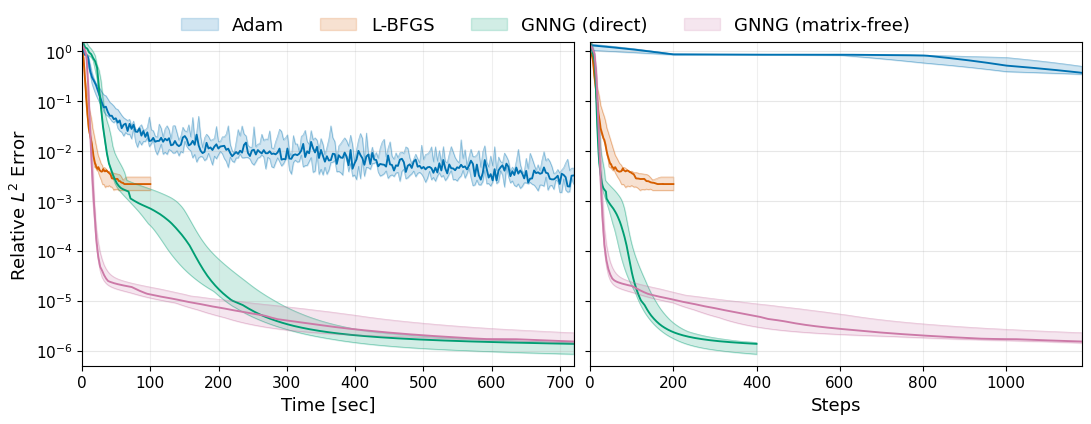

In [9]:
colors = method_colors(time_plot_groups)

with plt.rc_context({
    "font.size": FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "xtick.labelsize": FIGURE_TICK_FONT_SIZE,
    "ytick.labelsize": FIGURE_TICK_FONT_SIZE,
    "legend.fontsize": FIGURE_LEGEND_FONT_SIZE,
}):
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.8), sharey=True, constrained_layout=True)
    plot_aggregated_curves(
        time_plot_groups,
        x_label=X_AXIS_DISPLAY,
        y_label=PLOT_METRIC_DISPLAY,
        ax=axes[0],
        colors=colors,
        x_max=X_AXIS_MAX,
        show_legend=False,
    )
    plot_aggregated_curves(
        step_plot_groups,
        x_label=STEP_X_AXIS_DISPLAY,
        ax=axes[1],
        colors=colors,
        x_max=step_axis_max,
        show_legend=False,
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.10),
        ncol=len(labels),
        frameon=False,
    )

    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(CONVERGENCE_FIGURE_PATH, bbox_inches="tight")
    print(f"Saved figure to {CONVERGENCE_FIGURE_PATH}")
    plt.show()


## Figure: Ablations

Saved figure to /Users/klemens/Projects/EqNN-Equilibrium-Neural-Network/practical/docs/figures/kovasznay_ablation.pdf


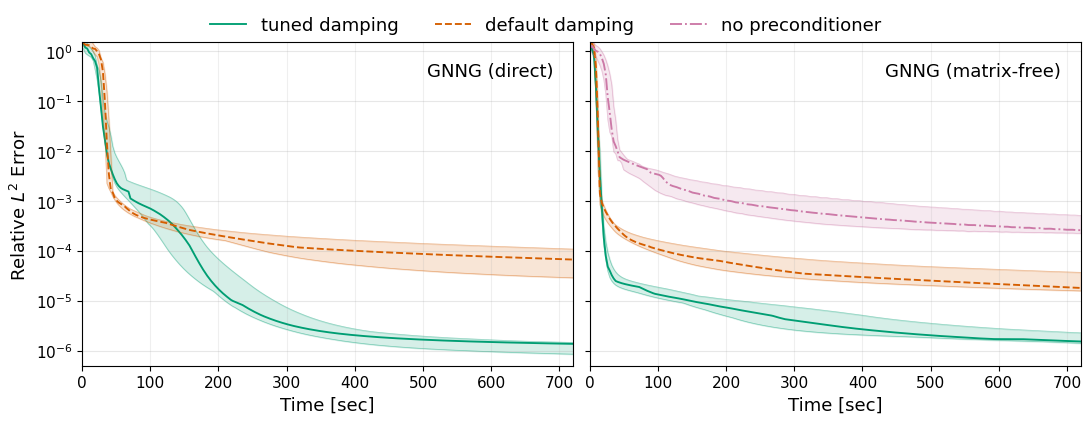

,method,label,median_steps
0,gnng_dense_v0,tuned damping,400.0
1,gnng_dense_v1,default damping,395.0
2,gnng_matfree_v0,tuned damping,1200.0
3,gnng_matfree_v1,default damping,849.0
4,gnng_matfree_v2,no preconditioner,282.0


In [10]:
ABLATION_FIGURE_PATH = FIGURES_DIR / "kovasznay_ablation.pdf"
ABLATION_TIME_MAX = X_AXIS_MAX

ABLATION_DISPLAY = {
    "gnng_dense_v0": "tuned damping",
    "gnng_dense_v1": "default damping",
    "gnng_matfree_v0": "tuned damping",
    "gnng_matfree_v1": "default damping",
    "gnng_matfree_v2": "no preconditioner",
}
ABLATION_COLORS = {
    "tuned damping": "#009E73",
    "default damping": "#D55E00",
    "no preconditioner": "#CC79A7",
}
ABLATION_LINESTYLES = {
    "tuned damping": "-",
    "default damping": "--",
    "no preconditioner": "-.",
}
ABLATION_MARKERS = {
    "tuned damping": None,
    "default damping": None,
    "no preconditioner": None,
}
ABLATION_PANELS = [
    ("GNNG (direct)", ["gnng_dense_v0", "gnng_dense_v1"]),
    ("GNNG (matrix-free)", ["gnng_matfree_v0", "gnng_matfree_v1", "gnng_matfree_v2"]),
]


def load_sweep_run_groups(sweep_dir: Path) -> dict[str, list[dict]]:
    assert sweep_dir.exists(), f"Sweep directory not found: {sweep_dir}"
    run_groups = defaultdict(list)
    for method_dir in sorted(path for path in sweep_dir.iterdir() if path.is_dir()):
        for summary_path in sorted(method_dir.glob("seed_*/summary.json")):
            metrics_path = summary_path.with_name("metrics.jsonl")
            if not metrics_path.exists():
                continue
            metrics = load_jsonl(metrics_path)
            if not metrics:
                continue
            run_groups[method_dir.name].append(
                {
                    "method_name": method_dir.name,
                    "summary_path": summary_path,
                    "metrics_path": metrics_path,
                    "summary": load_json(summary_path),
                    "metrics": metrics,
                }
            )
    return run_groups


def ablation_plot_groups(
    run_groups: dict[str, list[dict]],
    selected_method_names: list[str],
) -> list[tuple[str, list[dict], dict]]:
    plot_groups = []
    for method_name in selected_method_names:
        method_runs = run_groups.get(method_name, [])
        if not method_runs:
            continue
        aggregate = aggregate_curves(
            method_runs,
            x_key=X_AXIS,
            y_key=PLOT_METRIC,
            num_points=NUM_GRID_POINTS,
            x_max=ABLATION_TIME_MAX,
        )
        if aggregate is None:
            continue
        plot_groups.append((method_name, method_runs, aggregate))
    return plot_groups


def plot_ablation_panel(ax, plot_groups: list[tuple[str, list[dict], dict]], panel_label: str) -> None:
    for method_name, _, aggregate in plot_groups:
        label = ABLATION_DISPLAY[method_name]
        color = ABLATION_COLORS[label]
        ax.fill_between(
            aggregate["x"],
            aggregate["min"],
            aggregate["max"],
            color=color,
            alpha=0.16,
            label="_nolegend_",
        )
        ax.plot(aggregate["x"], aggregate["min"], color=color, linestyle="-", linewidth=0.5, alpha=0.35, label="_nolegend_")
        ax.plot(aggregate["x"], aggregate["max"], color=color, linestyle="-", linewidth=0.5, alpha=0.35, label="_nolegend_")
        ax.plot(
            aggregate["x"],
            aggregate["median"],
            color=color,
            linestyle=ABLATION_LINESTYLES[label],
            linewidth=1.35,
            marker=ABLATION_MARKERS[label],
            markevery=max(len(aggregate["x"]) // 8, 1),
            markersize=3.2,
            label=label,
        )

    if USE_LOG_Y:
        ax.set_yscale("log")
    ax.set_xlabel(X_AXIS_DISPLAY)
    ax.set_xlim(0, ABLATION_TIME_MAX)
    ax.set_ylim(5e-7, 1.5)
    y_ticks = [10**(-k) for k in range(7)]
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.xaxis.grid(True, which="major", alpha=0.2)
    ax.yaxis.grid(True, which="major", alpha=0.3)
    ax.text(0.96, 0.94, panel_label, transform=ax.transAxes, ha="right", va="top")


ablation_groups = load_sweep_run_groups(SWEEP_DIR)
ablation_panel_groups = [
    (panel_label, ablation_plot_groups(ablation_groups, panel_methods))
    for panel_label, panel_methods in ABLATION_PANELS
]
assert all(panel_groups for _, panel_groups in ablation_panel_groups), "Missing ablation plot groups."

ablation_step_summary = []
for method_name in [method for _, panel_methods in ABLATION_PANELS for method in panel_methods]:
    completed_steps = [run["summary"].get("completed_steps") for run in ablation_groups.get(method_name, [])]
    completed_steps = [float(value) for value in completed_steps if value is not None]
    if completed_steps:
        ablation_step_summary.append(
            {
                "method": method_name,
                "label": ABLATION_DISPLAY[method_name],
                "median_steps": float(np.median(completed_steps)),
            }
        )

with plt.rc_context({
    "font.size": FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "xtick.labelsize": FIGURE_TICK_FONT_SIZE,
    "ytick.labelsize": FIGURE_TICK_FONT_SIZE,
    "legend.fontsize": FIGURE_LEGEND_FONT_SIZE,
}):
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.8), sharey=True, constrained_layout=True)
    for ax, (panel_label, panel_groups) in zip(axes, ablation_panel_groups):
        plot_ablation_panel(ax, panel_groups, panel_label)
    axes[0].set_ylabel(PLOT_METRIC_DISPLAY)

    handles_by_label = {}
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        for handle, label in zip(handles, labels):
            handles_by_label.setdefault(label, handle)
    fig.legend(
        list(handles_by_label.values()),
        list(handles_by_label.keys()),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.10),
        ncol=len(handles_by_label),
        frameon=False,
    )

    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(ABLATION_FIGURE_PATH, bbox_inches="tight")
    print(f"Saved figure to {ABLATION_FIGURE_PATH}")
    plt.show()

pd.DataFrame(ablation_step_summary)


## Table: Hyperparameters

In [11]:
HYPERPARAM_METHODS = [
    ("gnng_dense_v0", "GNNG (direct)", "tuned"),
    ("gnng_dense_v1", "GNNG (direct)", "default"),
    ("gnng_matfree_v0", "GNNG (matrix-free)", "tuned"),
    ("gnng_matfree_v1", "GNNG (matrix-free)", "default"),
    ("gnng_matfree_v2", "GNNG (matrix-free)", "no precond."),
]


def latex_sci(value: float | None) -> str:
    if value is None or pd.isna(value):
        return r"\textemdash"
    value = float(value)
    if value == 1.0:
        return "1"
    mantissa, exponent = f"{value:.0e}".split("e")
    exponent = int(exponent)
    if mantissa == "1":
        return rf"$10^{{{exponent}}}$"
    return rf"${mantissa}\times 10^{{{exponent}}}$"


def latex_damping_floor(value: float | None) -> str:
    if value is None or pd.isna(value):
        return r"\textemdash"
    if float(value) <= 1e-15:
        return "no"
    return latex_sci(value)


def latex_damping_scale(value: float | None) -> str:
    if value is None or pd.isna(value):
        return r"\textemdash"
    if float(value) == 1.0:
        return "no"
    return latex_sci(value)


def config_for_method(sweep_dir: Path, method_name: str) -> dict:
    config_paths = sorted((sweep_dir / method_name).glob("seed_*/config.json"))
    assert config_paths, f"No config found for {method_name} in {sweep_dir}"
    return load_json(config_paths[0])


def preconditioner_label(backend: str, kwargs: dict) -> str:
    if backend != "matfree":
        return "n/a"
    return "yes" if kwargs.get("use_cg_precond", False) else "no"


def gnng_hyperparam_rows() -> list[dict]:
    rows = []
    for method_name, optimizer_label, variant_label in HYPERPARAM_METHODS:
        cfg = config_for_method(SWEEP_DIR, method_name)
        kwargs = cfg["optimizer"]["kwargs"]
        backend = kwargs.get("backend")
        rows.append(
            {
                "optimizer": optimizer_label,
                "variant": variant_label,
                "preconditioner": preconditioner_label(backend, kwargs),
                "damping_cap": kwargs.get("damping_cap"),
                "damping_floor": kwargs.get("damping_floor"),
                "damping_scale": kwargs.get("damping_scale"),
            }
        )
    return rows


def latex_gnng_hyperparam_rows(rows: list[dict]) -> str:
    lines = []
    previous_optimizer = None
    for idx, row in enumerate(rows):
        optimizer = row["optimizer"]
        optimizer_label = optimizer if optimizer != previous_optimizer else ""
        fields = [
            latex_escape(optimizer_label),
            latex_escape(row["variant"]),
            latex_escape(row["preconditioner"]),
            latex_sci(row["damping_cap"]),
            latex_damping_floor(row["damping_floor"]),
            latex_damping_scale(row["damping_scale"]),
        ]
        line = " & ".join(fields)
        if idx < len(rows) - 1:
            line += r"\\[0.65ex]"
        lines.append(line)
        previous_optimizer = optimizer
    return "\n".join(lines) + "\n"


hyperparam_rows = gnng_hyperparam_rows()
hyperparam_table = pd.DataFrame(hyperparam_rows)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
HYPERPARAM_TABLE_ROWS_PATH.write_text(latex_gnng_hyperparam_rows(hyperparam_rows), encoding="utf-8")
print(f"Saved table rows to {HYPERPARAM_TABLE_ROWS_PATH}")

hyperparam_table


Saved table rows to /Users/klemens/Projects/EqNN-Equilibrium-Neural-Network/practical/docs/tables/kovasznay_gnng_hyperparams_rows.tex


,optimizer,variant,preconditioner,damping_cap,damping_floor,damping_scale
0,GNNG (direct),tuned,n/a,0.00100,1.000000e-09,0.0010
1,GNNG (direct),default,n/a,0.00001,1.000000e-16,1.0000
2,GNNG (matrix-free),tuned,yes,0.00010,1.000000e-07,0.0001
3,GNNG (matrix-free),default,yes,0.00001,1.000000e-16,1.0000
4,GNNG (matrix-free),no precond.,no,0.00010,1.000000e-07,0.0001


## Table: Main Results


In [12]:
def result_table_rows() -> list[dict]:
    rows = []
    for method_name in method_names:
        method_runs = groups.get(method_name, [])
        if not method_runs:
            continue
        rows.append(
            {
                "optimizer": display_method_name(method_name),
                "rel_l2_u": median_metric(method_runs, "rel_l2_u"),
                "rel_l2_v": median_metric(method_runs, "rel_l2_v"),
                "rel_l2_p": median_metric(method_runs, "rel_l2_p"),
                "rel_l2_mean": median_metric(method_runs, "rel_l2_mean"),
                "step_cost_s": median_step_cost_to_best(method_runs),
                "peak_gpu_mem_mb": median_peak_gpu_mem_mb(method_runs),
            }
        )
    return rows


results_table_rows = result_table_rows()
results_table = pd.DataFrame(results_table_rows)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_TABLE_ROWS_PATH.write_text(latex_result_rows(results_table_rows), encoding="utf-8")
print(f"Saved table rows to {RESULTS_TABLE_ROWS_PATH}")

results_table


Saved table rows to /Users/klemens/Projects/EqNN-Equilibrium-Neural-Network/practical/docs/tables/kovasznay_results_rows.tex


,optimizer,rel_l2_u,rel_l2_v,rel_l2_p,rel_l2_mean,step_cost_s,peak_gpu_mem_mb
0,Adam,6.070980e-04,0.003617,0.001587,0.001937,0.010397,214.541992
1,L-BFGS,5.570713e-04,0.003965,0.001915,0.002174,0.392737,227.276855
2,GNNG (direct),3.673494e-07,0.000002,0.000001,0.000001,1.801041,1617.517578
3,GNNG (matrix-free),3.960124e-07,0.000003,0.000001,0.000002,0.600708,1536.812988
